<u>**Preamble**</u>: This is a data analysis and modeling project to predict voter party preference in Estonia on the basis of demographics. The intended process involves initial data exploration, followed by the construction, fitting, and analysis of a series of increasingly complex Bayesian categorical models. This Bayesian approach offers a robust alternative to traditional frequentist Analysis of Variance (ANOVA) methods commonly employed in scientific research and A/B/n testing in fields such as marketing, user experience (UX), and web design. A significant benefit of the Bayesian model is its inherent ability to quantify predictive uncertainty through the calculation of posterior (inferential) probability distributions, contrasting with the reliance on sampling distributions in frequentist procedures

<u>**Contents**</u>:

1. Exploratory Data Analysis
2. Modeling
    <br> $→$ Model Building and, Prior Elicitation and Prior Predictive Checks
    <br> $→$ Model Fitting and Goodness-of-Fit Analysis
    <br> $→$ Posterior Predictive Checks
    <br> $→$ Summary and Conclusion

 <u>**Data Provenance**</u>: This data is courtesy of [SALK](https://salk.ee/). SALK refers to the Liberal Citizen Foundation in Estonia; a political organization aimed at influencing Estonian policy and parliamentary elections. This foundation was established with the (ultimately attained) goal of helping liberal forces gain a majority in the 2023 Estonian parliamentary elections.

<u>**Acknowledgments**</u>: I thank [Alex Andorra](https://topmate.io/alex_andorra) and the folks at [Intuitive Bayes](https://www.intuitivebayes.com/) for helping me understand non-identifiability and overparameterization in statistical modeling.

In [87]:
import arviz as az
import matplotlib.pyplot as pp
from matplotlib import rcParams
import numpy as np
import pandas as pd

import pymc as pm

In [88]:
rcParams['font.size'] = 12

#### 1. Exploratory Data Analysis

In [2]:
data = pd.read_csv('./data/estonian-data.csv')

In [3]:
data.head().T

,0,1,2,3,4
age_group,16-24,16-24,16-24,16-24,16-24
education,Basic education,Basic education,Basic education,Basic education,Basic education
gender,Male,Male,Male,Male,Male
nationality,Estonian,Estonian,Estonian,Estonian,Estonian
electoral_district,"Haabersti, Põhja-Tallinn ja Kristiine",Harju- ja Raplamaa,Harju- ja Raplamaa,Harju- ja Raplamaa,Harju- ja Raplamaa
unit,Kristiine,Harjumaa,Harjumaa,Harjumaa,Harjumaa
EKRE,0,0,0,1,0
Eesti 200,0,0,0,0,0
Hard to say,0,0,0,0,0
Isamaa,0,0,0,0,0


I don't like the "Hard to say" column name; replace below with the clearer "Undecided" label.

In [4]:
data.rename(columns={'Hard to say': 'Undecided'}, inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5206 entries, 0 to 5205
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age_group            5206 non-null   object
 1   education            5206 non-null   object
 2   gender               5206 non-null   object
 3   nationality          5206 non-null   object
 4   electoral_district   5206 non-null   object
 5   unit                 5206 non-null   object
 6   EKRE                 5206 non-null   int64 
 7   Eesti 200            5206 non-null   int64 
 8   Undecided            5206 non-null   int64 
 9   Isamaa               5206 non-null   int64 
 10  Keskerakond          5206 non-null   int64 
 11  Mitte ükski erakond  5206 non-null   int64 
 12  Other                5206 non-null   int64 
 13  Parempoolsed         5206 non-null   int64 
 14  Reformierakond       5206 non-null   int64 
 15  Rohelised            5206 non-null   int64 
 16  SDE   

In [6]:
data.columns.tolist()

['age_group',
 'education',
 'gender',
 'nationality',
 'electoral_district',
 'unit',
 'EKRE',
 'Eesti 200',
 'Undecided',
 'Isamaa',
 'Keskerakond',
 'Mitte ükski erakond',
 'Other',
 'Parempoolsed',
 'Reformierakond',
 'Rohelised',
 'SDE']

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
EKRE,5206.0,0.124856,0.330587,0.0,0.0,0.0,0.0,1.0
Eesti 200,5206.0,0.082981,0.275880,0.0,0.0,0.0,0.0,1.0
Undecided,5206.0,0.127353,0.333400,0.0,0.0,0.0,0.0,1.0
Isamaa,5206.0,0.054552,0.227126,0.0,0.0,0.0,0.0,1.0
Keskerakond,5206.0,0.119285,0.324155,0.0,0.0,0.0,0.0,1.0
Mitte ükski erakond,5206.0,0.181521,0.385487,0.0,0.0,0.0,0.0,1.0
Other,5206.0,0.007876,0.088403,0.0,0.0,0.0,0.0,1.0
Parempoolsed,5206.0,0.002305,0.047960,0.0,0.0,0.0,0.0,1.0
Reformierakond,5206.0,0.215136,0.410956,0.0,0.0,0.0,0.0,1.0
Rohelised,5206.0,0.017480,0.131063,0.0,0.0,0.0,0.0,1.0


In [8]:
data.loc[:, 'EKRE':].sum(axis=1).describe().loc[['min', 'max']]

min    1.0
max    1.0
dtype: float64

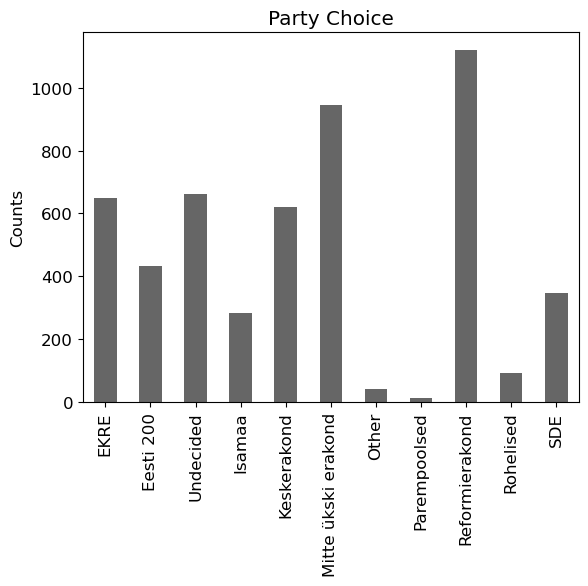

In [89]:
data.loc[:, 'EKRE':].sum(axis=0).plot(kind='bar', title='Party Choice', ylabel='Counts', color='black', alpha=0.6);

In [59]:
data.electoral_district.unique().size, data.unit.unique().size

(12, 24)

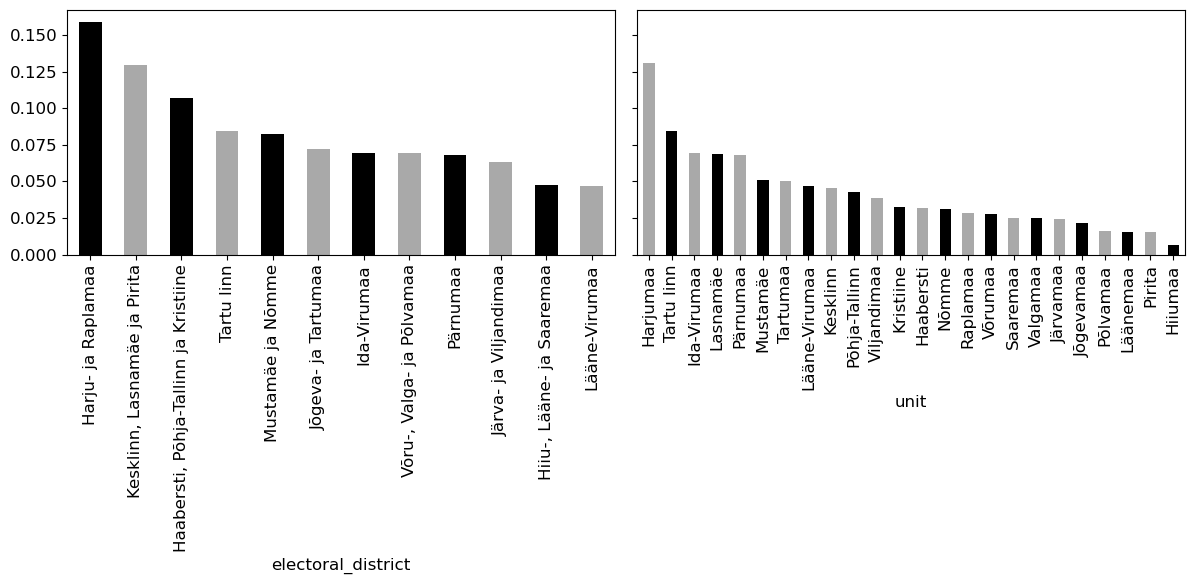

In [90]:
f, (left, right) = pp.subplots(ncols=2, figsize=(12, 6), sharey=True)
data.electoral_district.value_counts(normalize=True).plot(kind='bar', color=['black', 'darkgray'], ax=left)
data.unit.value_counts(normalize=True).plot(kind='bar', color=['darkgray', 'black'])
left.set_xticklabels(left.get_xticklabels(), rotation=90)
f.tight_layout();

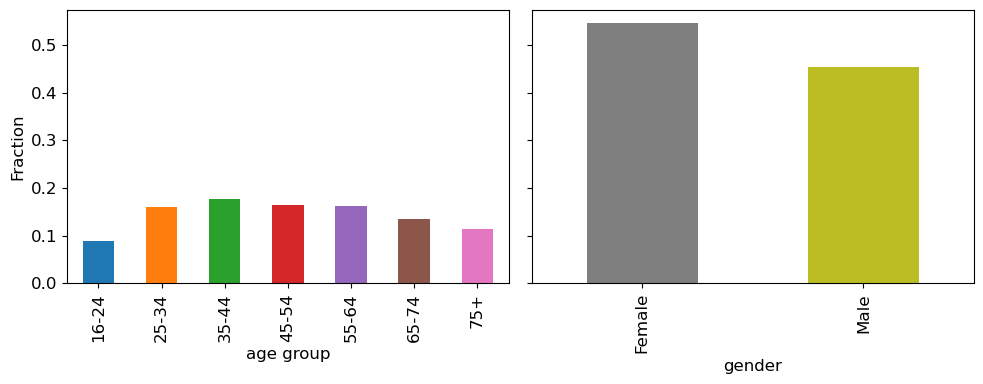

In [91]:
f, (left, right) = pp.subplots(ncols=2, figsize=(10, 4), sharey=True)
data.age_group.value_counts(normalize=True, sort=False).plot(kind='bar', color=[f'C{i}' for i in range(7)], ax=left);
data.gender.value_counts(normalize=True).plot(kind='bar', color= ['C7', 'C8'], ax=right)
left.set(ylabel='Fraction', xlabel='age group')
f.tight_layout()


In [11]:
data.education.value_counts()

education
Secondary education    2684
Higher education       1948
Basic education         574
Name: count, dtype: int64

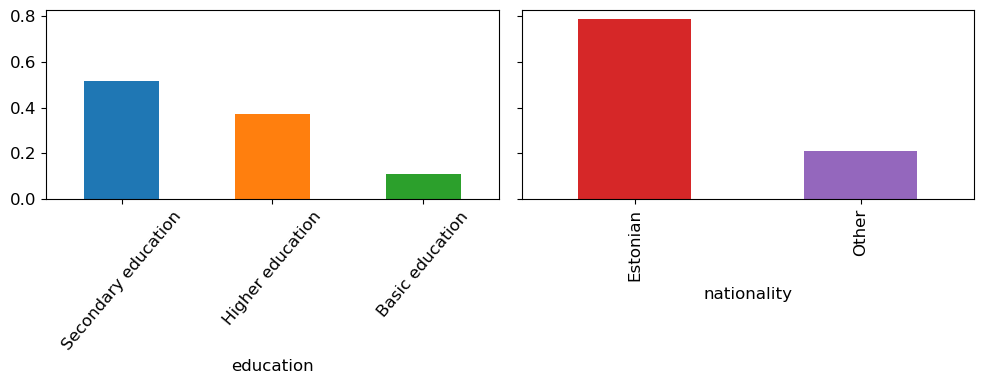

In [92]:
f, (left, right) = pp.subplots(ncols=2, figsize=(10, 4), sharey=True)
data.education.value_counts(normalize=True).plot(kind='bar', color=[f'C{i}' for i in range(0, 3)], ax=left)
data.nationality.value_counts(normalize=True).plot(kind='bar', color=['C3', 'C4'])
left.set_xticklabels(left.get_xticklabels(), rotation=50)
f.tight_layout();

##### Preliminary summary:

This table registers voter preference. Each row is a voter. Columns include voter demographics, the election district and unit. The rest of the columns are each dedicated to a party.  Data are in the thousands with no apparent missing value.
There are two types of data; (1) strings that lend themselves to categorization, and (2) binary data indicating whether a given party has received the vote of that row's  voter. There were no irregularities, i.e. more than 1 vote registered for each person;  there were no abstentions noted in this dataset either. 
All the data is categorical with the following number of categories:
* Party choice $→$ 11
* Electoral district $\rightarrow$ 12
* (Electoral) Unit $→$ 24
* AGe group $→$ 7
* Gender $→$ 2
* Education $→$ 3
* Nationality $→$ 2



##### Preliminary summary, part 2: 
There is some imbalance in education level, with secondary education being the more proeminent. There is notable imbalance in nationality, with predictable majority of Estonian representation. Party choice, electoral district and unit are also quite imbalanced. Next is to examine party representation breakdown at the  group level. Note that I will not consider electoral district and unit hereafter as the emphasis is on demographics as a driver of party choice.

In [13]:
def make_group_percentage(df: pd.DataFrame, category: 'str') -> pd.DataFrame:
    """Computes percentage for each column in a group"""
    group = df.groupby(category).sum(numeric_only=True)
    group_percent = group.div(group.sum(axis=1), axis=0)*100
    return group_percent


In [14]:
party_names = data.loc[:, 'EKRE':].columns.tolist()
party_names

['EKRE',
 'Eesti 200',
 'Undecided',
 'Isamaa',
 'Keskerakond',
 'Mitte ükski erakond',
 'Other',
 'Parempoolsed',
 'Reformierakond',
 'Rohelised',
 'SDE']

In [15]:
data.head()

,age_group,education,gender,nationality,electoral_district,unit,EKRE,Eesti 200,Undecided,Isamaa,Keskerakond,Mitte ükski erakond,Other,Parempoolsed,Reformierakond,Rohelised,SDE
0,16-24,Basic education,Male,Estonian,"Haabersti, Põhja-Tallinn ja Kristiine",Kristiine,0,0,0,0,0,1,0,0,0,0,0
1,16-24,Basic education,Male,Estonian,Harju- ja Raplamaa,Harjumaa,0,0,0,0,0,0,0,0,1,0,0
2,16-24,Basic education,Male,Estonian,Harju- ja Raplamaa,Harjumaa,0,0,0,0,0,0,0,0,0,0,1
3,16-24,Basic education,Male,Estonian,Harju- ja Raplamaa,Harjumaa,1,0,0,0,0,0,0,0,0,0,0
4,16-24,Basic education,Male,Estonian,Harju- ja Raplamaa,Harjumaa,0,0,0,0,1,0,0,0,0,0,0


In [16]:
data.groupby('gender').sum(
numeric_only=True
)

,EKRE,Eesti 200,Undecided,Isamaa,Keskerakond,Mitte ükski erakond,Other,Parempoolsed,Reformierakond,Rohelised,SDE
gender,,,,,,,,,,,
Female,271,237,412,119,374,507,18,7,620,55,225
Male,379,195,251,165,247,438,23,5,500,36,122


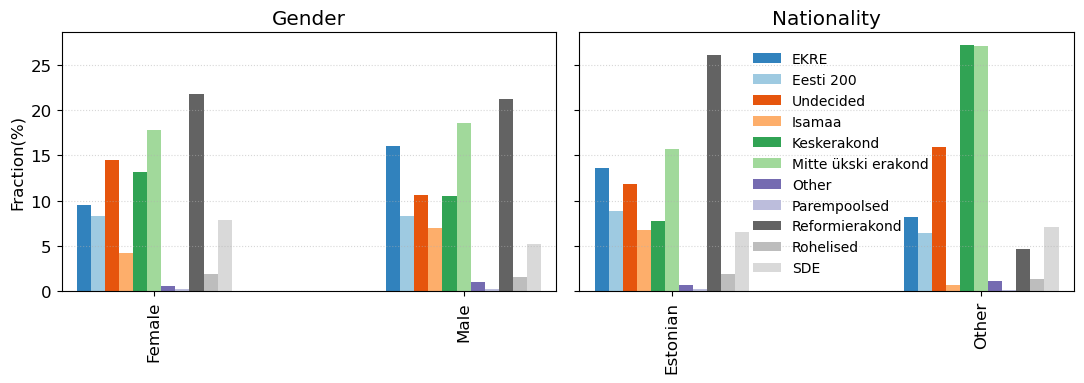

In [93]:
f, (left, right) = pp.subplots(ncols=2, figsize=(11, 4), sharey=True)
#gender = data.groupby('gender').sum(numeric_only=True)
#(gender.div(gender.sum(axis=1), axis=0)*100).plot(kind='bar', colormap='tab20c', ax=left, legend=False)
#data.groupby('nationality').sum(numeric_only=True).plot(kind='bar', colormap='tab20c', ax=right, legend=False)
make_group_percentage(data, 'gender').plot(kind='bar', colormap='tab20c', ax=left, legend=False)
make_group_percentage(data, 'nationality').plot(kind='bar', colormap='tab20c', ax=right)
left.set(title='Gender', ylabel='Fraction(%)', xlim=(-0.3, 1.3), xlabel='')
right.set(xlim=(-0.3, 1.3), title='Nationality', xlabel='')
right.legend(frameon=False, loc=(0.34 ,0.04), fontsize=10)
right.grid(axis='y', alpha=0.5, ls=':')
left.grid(axis='y', alpha=0.5, ls=':')
f.tight_layout();

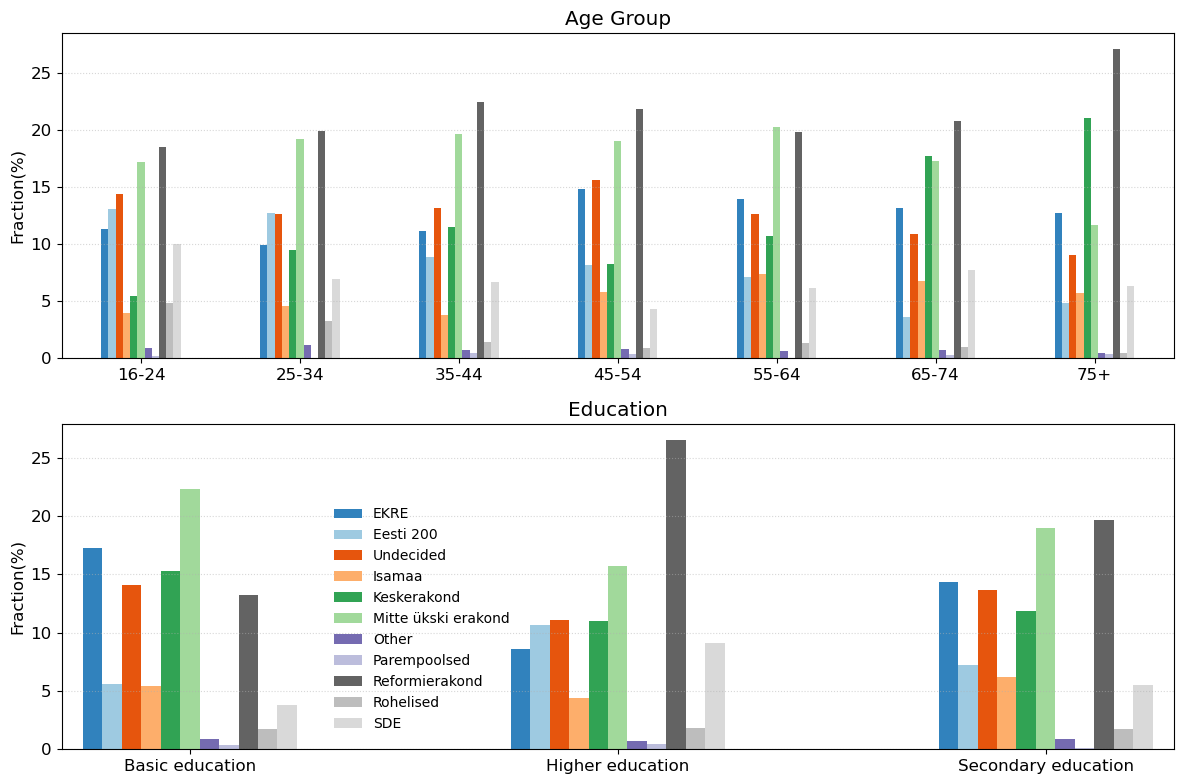

In [94]:
f, (top, bottom) = pp.subplots(nrows=2, figsize=(12, 8))
#data.groupby('age_group').sum(numeric_only=True)
make_group_percentage(data, 'age_group').plot(kind='bar', colormap='tab20c', ax=top, legend=False)
#data.groupby('education').sum(numeric_only=True)
make_group_percentage(data, 'education').plot(kind='bar', colormap='tab20c', ax=bottom, legend=False, )
top.set(title='Age Group', ylabel='Fraction(%)', xlabel='')
top.set_xticklabels(top.get_xticklabels(), rotation=0)
bottom.legend(frameon=False,  loc=(0.24, 0.04), fontsize=10)
bottom.set_xticklabels(bottom.get_xticklabels(), rotation=0)
bottom.set(ylabel='Fraction(%)', title='Education', xlim=(-0.3, 2.3), xlabel='')
bottom.grid(axis='y', alpha=0.5, ls=':')
top.grid(axis='y', alpha=0.5, ls=':')
f.tight_layout();

#### Grouped data summary
1. Overall
    * Reformierakond (a liberal party) is pretty popular across the board except with non-Estonians; 
    * Non-Estonians - I'm told - is almost entirely composed up of Russians;
    * There is a fair amount of undecided voters;
    * EKRE and Keskeradon are populist parties - EKRE is right-wing, Keskerakond is center-left;
    * Parempoolsed, center-right party is the underdog across the board.

2. Group-specific
    * *Gender*: there are some subtle  differences. 
        * Reformierakond is slightly more popular with female voters;
        * There are more undecided among female voters;
        * The right-wing EKRE is more popular with male voters.
    * *Nationality*:
        * Reformierakond, EKRE are more popular with Estonians;
        * Keskerakond, Mitte ukski erakond are favored by ethnic Russians who are also more numerous to be undecided. 
    * *Age group*:
        * Mitte ukski erakond and Reformierakond are the two prevaiing parties among each age group except the two older tranches;
        * Among 65 and over Reformierakond retains the top but Mitte recedes in favor of Keskeradond.
    * *Education*:
        * EKRE, Undecided, Mitte ukski erakond are the top 3 party choices for those with a basic education;
        * Reformierakond and Mitte are the top 2 party choices among those with a college degree.
        * High school graduates exhibit a preference for Reformierakond, Mitte, and EKRE.

#### 2. Modeling

The goal is to predict party preference on the basis of available demographic data. 
I will first start with looking at two categories; education and nationality. The below is some data encoding to ease model fitting and clarity of plotted results. In particular note the model coordinate names; 'party_choice', 'education', 'nationality', 'obs_idx'. The latter is just the row index of the dataframe containing the observations; each row corresponding to one observation.

In [19]:
# response variable encoding
party_choice = pd.Categorical(data[party_names].idxmax(axis=1), categories=party_names, ordered=True)
party_choice_label = party_choice.categories.to_list()
party_choice_code = party_choice.codes

# input variables encoding
education_code, education_label = data.education.factorize(sort=True) 
nationality_code, nationality_label = data.nationality.factorize(sort=True)

# setting model coordinates

coords = {
    'party_choice': party_choice_label,
    'education': education_label,
    'nationality': nationality_label,
    'obs_idx': data.index} # observation index, the row location of an observation in the dataframe.

Below I write a first model using a baseline intercept and I use nationality and education as predictors and baseline offsets. The corresponding coefficients have 'party choice' as dimension (11 possibilities) and in the case of education and nationality, have  also a dimension of 'education' (3 possibilities) and 'nationality' (2 possibilities), respectively. These are linearly combined and passed to a softmax function to scale the output to the $(0-1)$ interval, as shown below.
$$ p = softmax(α_{baseline} + α_{nationality}[\small{nationality\_category}] + α_{education}[\small{education\_category}]) $$

As prior distribution for all three coefficients, instead of using the $\mathcal{Normal}$ distribution, I use below the $\mathcal{Zero-sum\ Normal}$. This distribution imposes zero sum constraints on specified axes of the fitted coefficients, thereby addressing the problem of overparameterization and identifiability that often plague categorical regression models; a subject of my blog post found [here](insert link). 

Finally I use for likelihood the $\mathcal{Categorical}$ distribution, which is a n-dimensional $\mathcal{Bernoulli}$ process, and through which I expose the model to the data.

In [20]:
def build_model1(α_sigma=1, α_nat_sigma=1, α_edu_sigma=1):
    with pm.Model(coords=coords) as model1:
        # Data containers
        party_choice_idx = pm.Data('party_choice_index', party_choice_code, dims='obs_idx')
        nationality_idx = pm.Data('nationality_index', nationality_code, dims='obs_idx')
        education_idx = pm.Data('eductation_index', education_code, dims='obs_idx')
        
        # Model priors
        # baseline
        α = pm.ZeroSumNormal('α', sigma=α_sigma, dims='party_choice') 
        # baseline offset due to nationality
        α_nationality = pm.ZeroSumNormal('α_nationality', sigma=α_nat_sigma, dims=('nationality', 'party_choice'), n_zerosum_axes=2) 
        # baseline offset due to education
        α_education = pm.ZeroSumNormal('α_education', sigma=α_edu_sigma, dims=('education', 'party_choice'), n_zerosum_axes=2)

        # Link function for choice probability
        p = pm.math.softmax(α + α_nationality[nationality_idx] + α_education[education_idx], axis=-1)
        
        # Likelihood
        _ = pm.Categorical('y', p=p, observed=party_choice_idx, dims='obs_idx')
    return model1


In [61]:
model1 = build_model1()

Below is the model's diagram with dimension information included. 

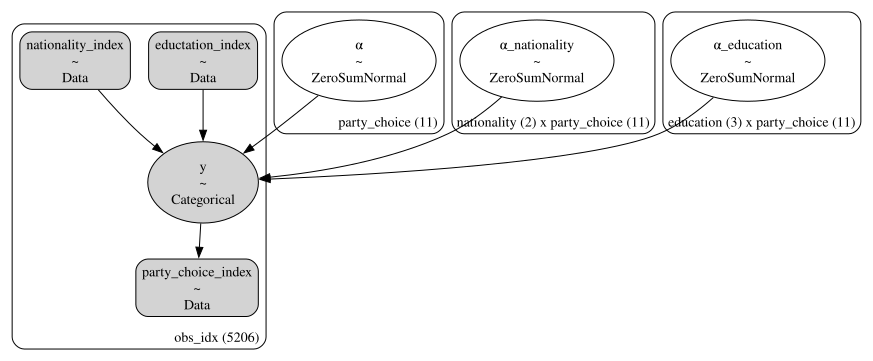

In [95]:
model1.to_graphviz()

Next is to sample model priors to see the soundness of assumptions made

In [63]:
with model1:
    idata1 = pm.sample_prior_predictive(model=model1)
    idata1.extend(pm.sample(chains=4, draws=2000, random_seed=42))
    idata1.extend(pm.sample_posterior_predictive(idata1))

Sampling: [y, α, α_education, α_nationality]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, α_nationality, α_education]


Output()

Sampling 4 chains for 1_000 tune and 1_999 draw iterations (4_000 + 7_996 draws total) took 95 seconds.
Sampling: [y]


Output()

In [ ]:
def plot_forward_samples(
        idata: az.InferenceData, categories:list, categories_name:str, 
        figsize=(12, 6), plot_prior=True, plot_posterior=True):
    """A quick function to plot model predictives. """
    f, (left, right) = pp.subplots(1, 2, figsize=figsize, sharey=True)
    xticks = [i + 0.5 for i in range(len(categories))]
    if plot_prior:
        az.plot_ppc(idata, group="prior", ax=left)
        left.set(
            xticks=xticks,
        )
        left.set_xticklabels(categories, fontsize=10, rotation=30)
        left.set_xlabel(categories_name, fontsize=16)
        left.legend(frameon=True, fontsize=11)
    else:
        left.set_visible(False)

    if plot_posterior:
        az.plot_ppc(idata, ax=right)
        right.set(
            xticks=xticks,
        )
        right.set_xticklabels(categories, fontsize=10, rotation=30)
        right.set_xlabel(categories_name, fontsize=16)
        right.legend(frameon=True, fontsize=11)
    else:
        right.set_visible(False)
    f.tight_layout()
    return f, (left, right)

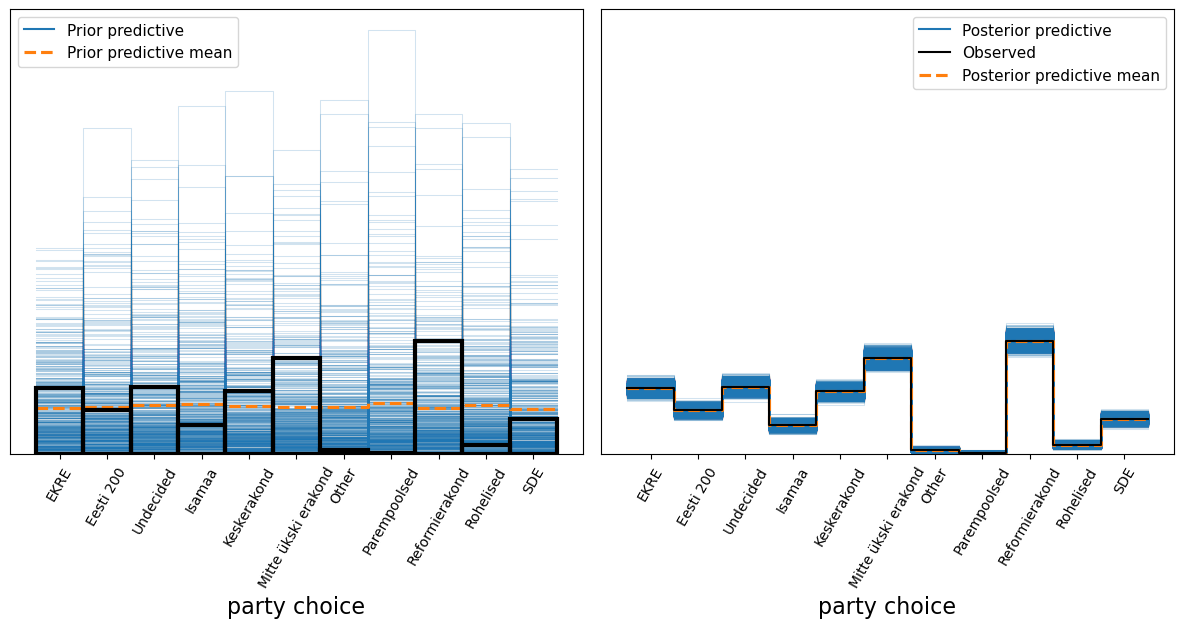

In [96]:
mean_win = pd.Series(party_choice_code).value_counts(normalize=True).round(3).sort_index()
f, (axl, axr) = plot_forward_samples(idata1, categories=party_choice_label, categories_name='party choice', figsize=(12, 6))
axl.set_xticklabels(axl.get_xticklabels(), rotation=60);
axl.bar(x=axl.get_xticks(), height=mean_win.values,  color='k', fill=False, lw=3, width=1, zorder=13, label='data');
axr.set_xticklabels(axr.get_xticklabels(), rotation=60);

Left, in blue lines are sample outcomes for each party choice, before the model has seen the data. Right, model fit results (posterior distribution for each category). The model seems to have learned the posterior distribution well. The model did take some time to fit though and in spite of the lack of difergences, one wonders if sampling could be more efficient. Domain experts have suggested a tighter variance on the coefficient priors could indeed ease sampling. Model1b integrates this domain knowledge as follows: 

In [35]:
model1b = build_model1(α_sigma=0.5, α_edu_sigma=0.2, α_nat_sigma=0.3)

In [36]:
with model1b:
    idata1b = pm.sample_prior_predictive()
    idata1b.extend(pm.sample(chains=4, draws=2000, random_seed=42))
    idata1b.extend(pm.sample_posterior_predictive(idata1b))

Sampling: [y, α, α_education, α_nationality]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, α_nationality, α_education]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 82 seconds.
Sampling: [y]


Output()

There was some speed improvement (~ 18 seconds on a Macbook air M2.)
#### Assessing goodness of fit

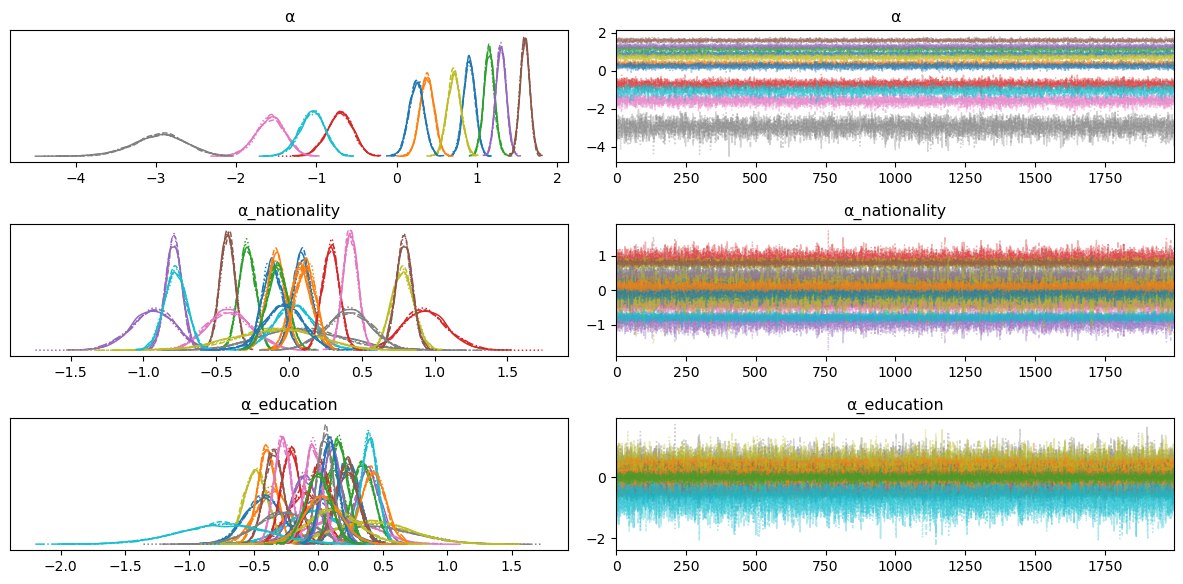

In [98]:
az.plot_trace(idata1, backend_kwargs={'tight_layout': True});

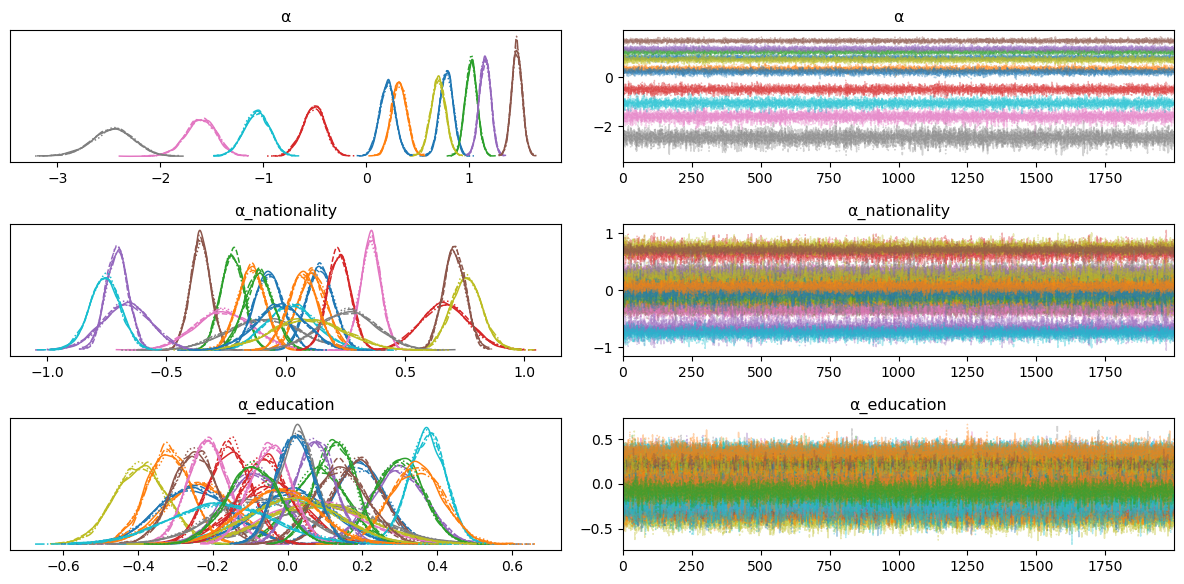

In [99]:
az.plot_trace(idata1b, backend_kwargs=dict(tight_layout=True));

Good mixing in the chains and lack of divergences suggest a good fit. The second model (bottom panel) has tighter posteriors, suggesting a slightly better fit.

In [ ]:
az.summary(idata1, var_names='α')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[EKRE],0.906,0.072,0.772,1.042,0.001,0.001,6612.0,6756.0,1.0
α[Eesti 200],0.377,0.087,0.222,0.549,0.001,0.001,6715.0,6112.0,1.0
α[Undecided],1.153,0.067,1.021,1.277,0.001,0.001,6441.0,6223.0,1.0
α[Isamaa],-0.710,0.160,-1.000,-0.405,0.002,0.001,8356.0,6113.0,1.0
α[Keskerakond],1.302,0.063,1.178,1.415,0.001,0.001,6106.0,6320.0,1.0
α[Mitte ükski erakond],1.599,0.059,1.486,1.709,0.001,0.001,5842.0,5910.0,1.0
α[Other],-1.575,0.180,-1.900,-1.225,0.002,0.001,10091.0,6406.0,1.0
α[Parempoolsed],-2.961,0.326,-3.584,-2.365,0.004,0.003,5747.0,6096.0,1.0
α[Reformierakond],0.716,0.084,0.552,0.865,0.001,0.001,8024.0,6563.0,1.0
α[Rohelised],-1.054,0.156,-1.340,-0.752,0.002,0.001,8262.0,6252.0,1.0


In [67]:
az.summary(idata1b, var_names='α')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[EKRE],0.781,0.064,0.660,0.899,0.001,0.000,12336.0,6688.0,1.0
α[Eesti 200],0.320,0.073,0.176,0.452,0.001,0.001,10479.0,6316.0,1.0
α[Undecided],1.020,0.058,0.907,1.126,0.001,0.000,10735.0,6572.0,1.0
α[Isamaa],-0.509,0.109,-0.723,-0.310,0.001,0.001,10705.0,5825.0,1.0
α[Keskerakond],1.155,0.055,1.049,1.253,0.001,0.000,10455.0,6907.0,1.0
α[Mitte ükski erakond],1.464,0.051,1.370,1.563,0.001,0.000,9276.0,6427.0,1.0
α[Other],-1.609,0.147,-1.889,-1.333,0.001,0.001,12469.0,6006.0,1.0
α[Parempoolsed],-2.461,0.202,-2.849,-2.089,0.002,0.001,10961.0,5924.0,1.0
α[Reformierakond],0.698,0.071,0.563,0.830,0.001,0.000,10962.0,6083.0,1.0
α[Rohelised],-1.065,0.121,-1.295,-0.843,0.001,0.001,10573.0,6503.0,1.0


Looking at the model fit summary tables for the baseline $α$ parameter, in both cases the $\hat{R}$ (aka *Gelman-Rubin* statistic) is 1.0. This indicates good convergence of MCMC chains (I fired up 4 of them for sampling). Interestingly however, in the case of the second model with tighter variance constraints on the priors, the *Effective Sample Size* corresponding to the sampling of the central portion of the posterior (ess_bulk) shows more efficient sampling in most cases. The posterior is therefore likelier to be better characterized. A similar pattern can be observed in the next 4 tables for $α_{nationality}$ and $α_{education}$. Note that in contrast, the tails of the posterior are sampled with similar efficiency in both cases, as noted by ess_tail. 

In [68]:
az.summary(idata1, var_names='α_education')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"α_education[Basic education, EKRE]",0.234,0.088,0.072,0.400,0.001,0.001,8283.0,6424.0,1.0
"α_education[Basic education, Eesti 200]",-0.359,0.125,-0.602,-0.134,0.001,0.001,8963.0,6073.0,1.0
"α_education[Basic education, Undecided]",0.110,0.091,-0.052,0.290,0.001,0.001,8564.0,6634.0,1.0
"α_education[Basic education, Isamaa]",-0.110,0.129,-0.352,0.130,0.001,0.001,12840.0,6267.0,1.0
"α_education[Basic education, Keskerakond]",0.385,0.091,0.212,0.555,0.001,0.001,7643.0,6643.0,1.0
"α_education[Basic education, Mitte ükski erakond]",0.226,0.082,0.067,0.376,0.001,0.001,6870.0,6415.0,1.0
"α_education[Basic education, Other]",0.148,0.276,-0.357,0.665,0.003,0.003,9155.0,5880.0,1.0
"α_education[Basic education, Parempoolsed]",0.332,0.382,-0.402,1.037,0.004,0.003,9247.0,6316.0,1.0
"α_education[Basic education, Reformierakond]",-0.486,0.092,-0.658,-0.317,0.001,0.001,9584.0,6477.0,1.0
"α_education[Basic education, Rohelised]",-0.054,0.205,-0.446,0.317,0.002,0.002,10698.0,6127.0,1.0


In [69]:
az.summary(idata1b, var_names='α_education')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"α_education[Basic education, EKRE]",0.191,0.070,0.055,0.320,0.001,0.000,13539.0,6375.0,1.0
"α_education[Basic education, Eesti 200]",-0.235,0.090,-0.400,-0.062,0.001,0.001,11990.0,7072.0,1.0
"α_education[Basic education, Undecided]",0.083,0.073,-0.060,0.214,0.001,0.001,12012.0,6297.0,1.0
"α_education[Basic education, Isamaa]",-0.050,0.093,-0.231,0.118,0.001,0.001,13607.0,6170.0,1.0
"α_education[Basic education, Keskerakond]",0.295,0.074,0.156,0.434,0.001,0.000,12671.0,6260.0,1.0
"α_education[Basic education, Mitte ükski erakond]",0.189,0.066,0.060,0.309,0.001,0.000,12424.0,6586.0,1.0
"α_education[Basic education, Other]",0.065,0.135,-0.184,0.323,0.001,0.001,13651.0,6458.0,1.0
"α_education[Basic education, Parempoolsed]",0.097,0.144,-0.174,0.365,0.001,0.001,13581.0,5944.0,1.0
"α_education[Basic education, Reformierakond]",-0.393,0.070,-0.517,-0.256,0.001,0.000,11899.0,6095.0,1.0
"α_education[Basic education, Rohelised]",0.009,0.122,-0.223,0.228,0.001,0.001,13491.0,6665.0,1.0


In [70]:
az.summary(idata1, var_names='α_nationality')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"α_nationality[Estonian, EKRE]",0.091,0.064,-0.031,0.210,0.001,0.001,7286.0,6415.0,1.0
"α_nationality[Estonian, Eesti 200]",0.081,0.072,-0.059,0.213,0.001,0.001,8745.0,6467.0,1.0
"α_nationality[Estonian, Undecided]",-0.287,0.058,-0.394,-0.182,0.001,0.001,6731.0,6374.0,1.0
"α_nationality[Estonian, Isamaa]",0.935,0.151,0.659,1.227,0.002,0.001,8994.0,5850.0,1.0
"α_nationality[Estonian, Keskerakond]",-0.791,0.056,-0.888,-0.677,0.001,0.000,6692.0,6269.0,1.0
"α_nationality[Estonian, Mitte ükski erakond]",-0.422,0.052,-0.520,-0.327,0.001,0.000,6272.0,6148.0,1.0
"α_nationality[Estonian, Other]",-0.407,0.155,-0.703,-0.120,0.001,0.001,12247.0,6221.0,1.0
"α_nationality[Estonian, Parempoolsed]",0.095,0.292,-0.427,0.655,0.004,0.003,5913.0,5237.0,1.0
"α_nationality[Estonian, Reformierakond]",0.780,0.076,0.639,0.921,0.001,0.001,8728.0,6381.0,1.0
"α_nationality[Estonian, Rohelised]",0.039,0.135,-0.209,0.290,0.001,0.001,10897.0,6032.0,1.0


In [71]:
az.summary(idata1b, var_names='α_nationality')

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"α_nationality[Estonian, EKRE]",0.144,0.057,0.039,0.251,0.001,0.000,12637.0,6667.0,1.0
"α_nationality[Estonian, Eesti 200]",0.112,0.062,-0.006,0.229,0.001,0.000,11945.0,6603.0,1.0
"α_nationality[Estonian, Undecided]",-0.223,0.049,-0.315,-0.136,0.000,0.000,11503.0,7039.0,1.0
"α_nationality[Estonian, Isamaa]",0.669,0.101,0.476,0.854,0.001,0.001,11064.0,6258.0,1.0
"α_nationality[Estonian, Keskerakond]",-0.707,0.046,-0.795,-0.621,0.000,0.000,11305.0,6511.0,1.0
"α_nationality[Estonian, Mitte ükski erakond]",-0.357,0.043,-0.439,-0.277,0.000,0.000,10679.0,6792.0,1.0
"α_nationality[Estonian, Other]",-0.260,0.121,-0.489,-0.035,0.001,0.001,12611.0,6075.0,1.0
"α_nationality[Estonian, Parempoolsed]",-0.091,0.153,-0.378,0.192,0.001,0.001,11387.0,6724.0,1.0
"α_nationality[Estonian, Reformierakond]",0.758,0.065,0.630,0.875,0.001,0.000,12215.0,6441.0,1.0
"α_nationality[Estonian, Rohelised]",0.026,0.105,-0.156,0.236,0.001,0.001,12021.0,6444.0,1.0


Given the above, I hereafter drop the first model with the more naive priors and continue with the second model with the more informative priors.


Now to check the impact of each predictor on voter preference by examining the posterior distribution, its central tendency and spread and how it relates to the reference value of 0, which corresponds to to effect. Note that: 
* The orange number situates probabilistically the reference value (0=neither favorable nor unfavorable.)
* The black line corresponds to the 94% Highest Density Interval (HDI) - the narrowest interval containing 94% of the posterior distribution. 
    * The choice of 94% is a reminder that there is nothing magical about this number. Analysts should determine the appropriate size of the credibility interval that works best for their use case.  
    * This corresponds to a proabilistic statement; i.e. there is a 94% chance that given this data and this model, a voter correponding to this category would have an an offset within the HDI.

1. Baseline - average voter tendencies
    * On average there is a overwhelmingly positive outlook on EKRE, Eesti, Mitte, Reformierakond, and to a lesser extent, SDE. The average voter has also a high probability of being Undecided.
    * On the other hand, Isamaa, Parempoolsed, Rohelised and smaller parties grouped under the catch-all Other are not likely to be appealing to the average voter. 

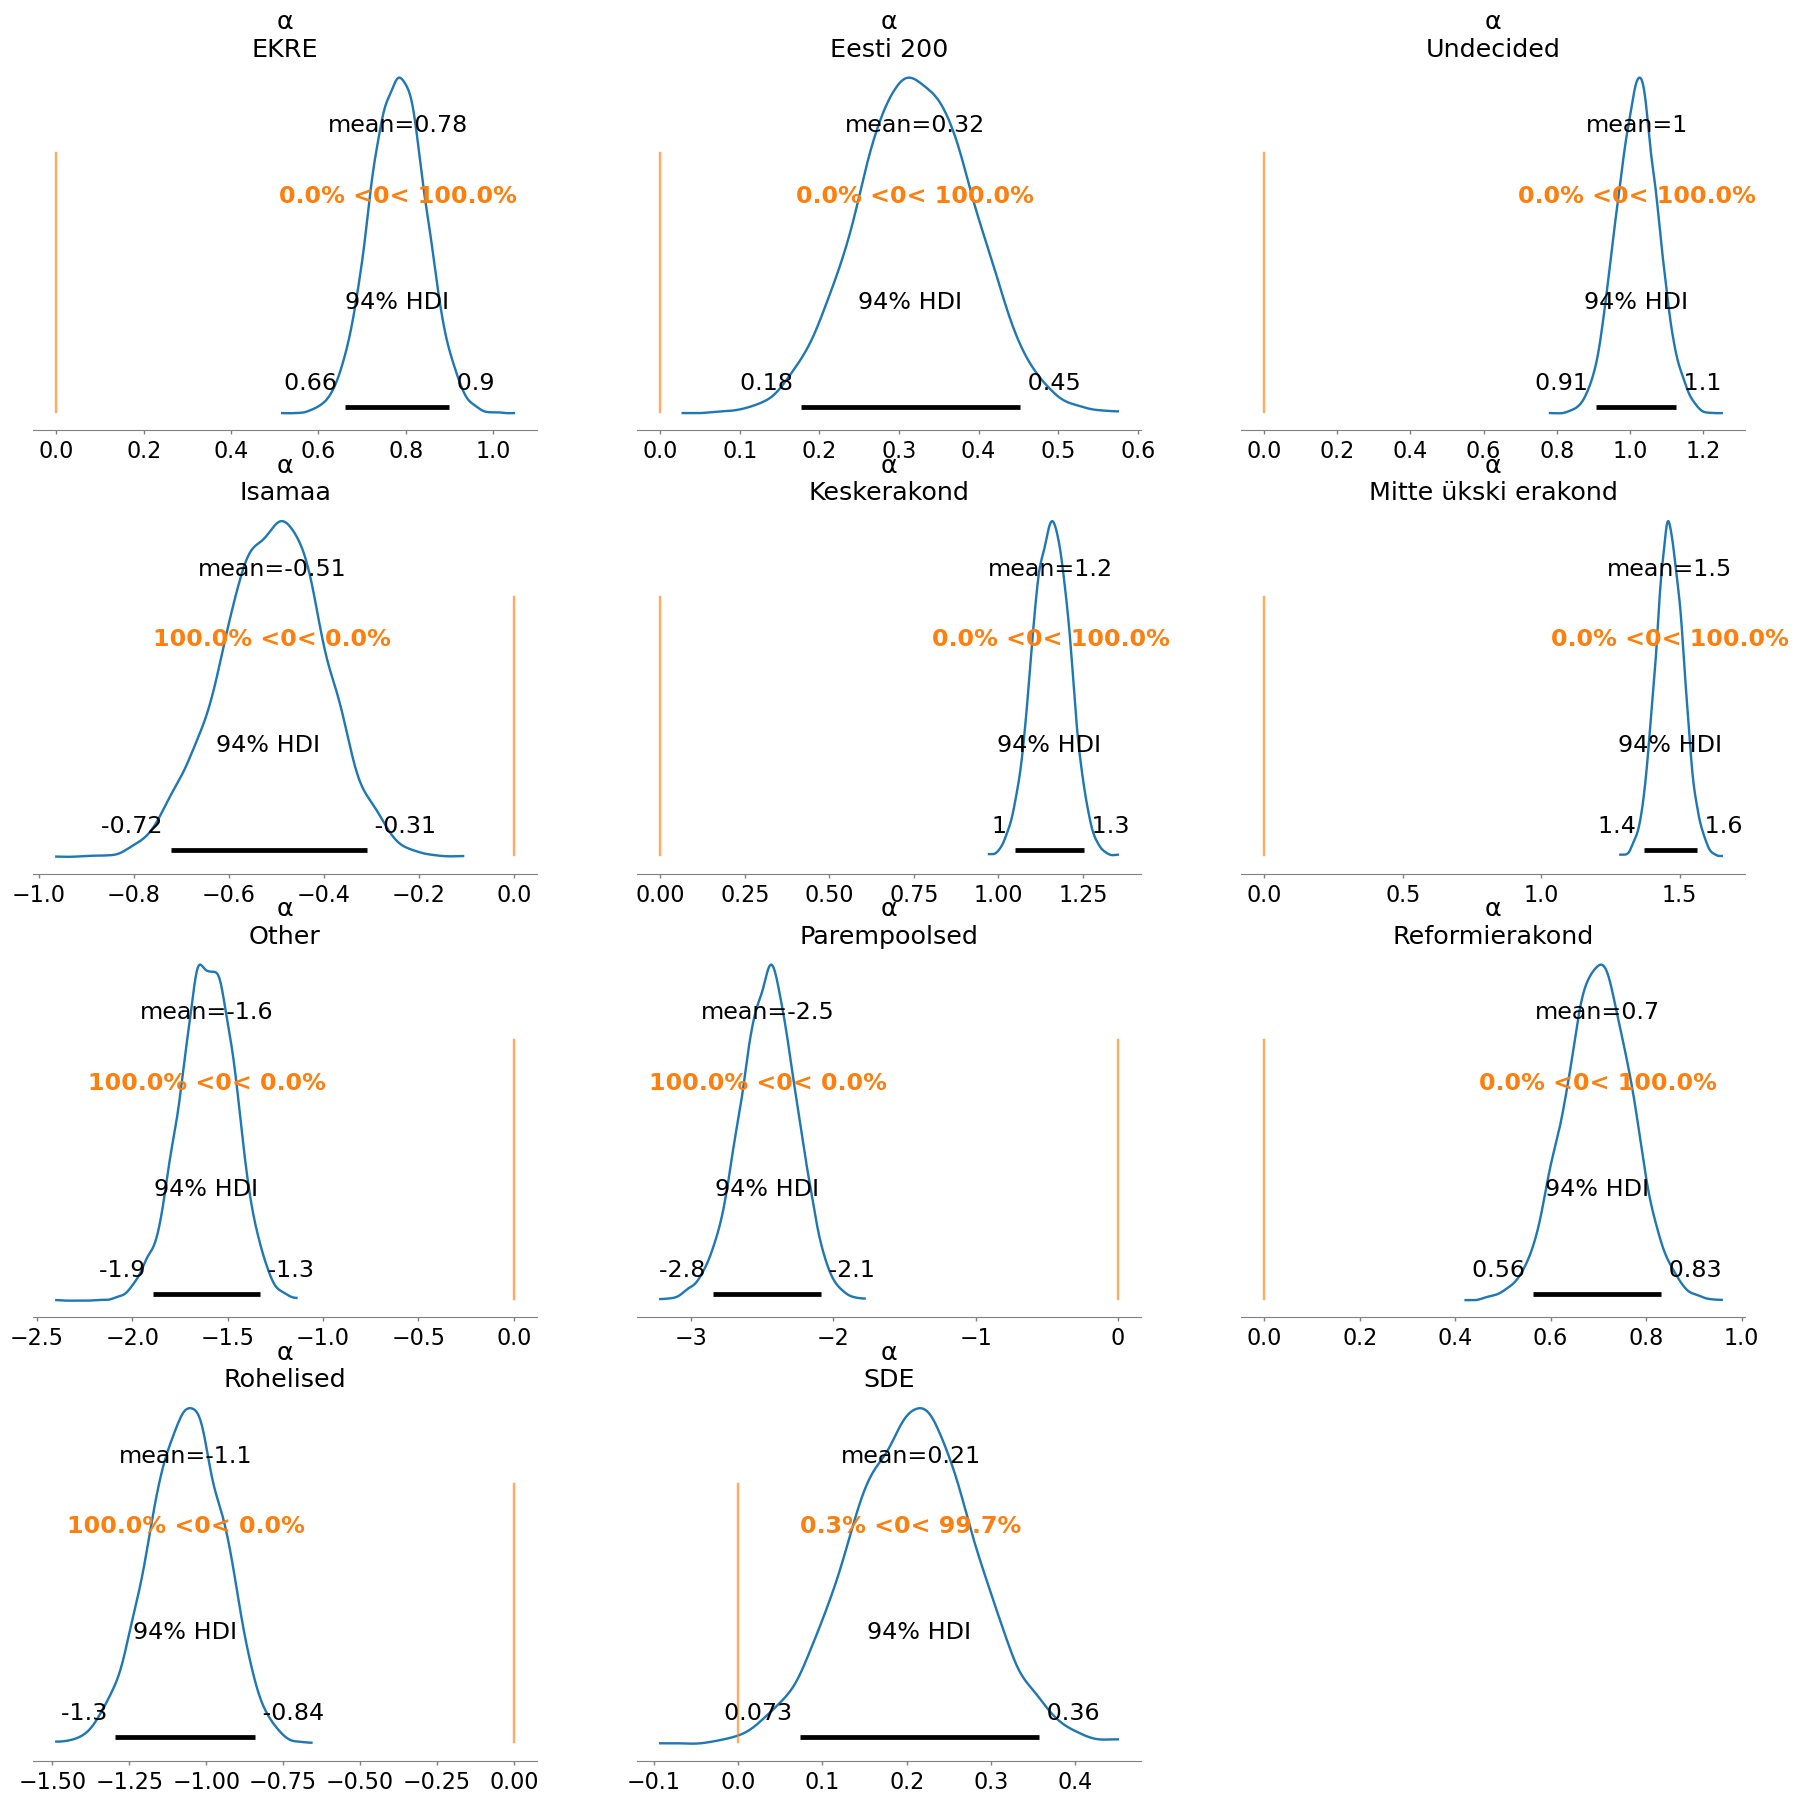

In [112]:
az.plot_posterior(idata1b, var_names='α', ref_val=0, textsize=16);


2. Education:
    * Basic Education: 
        * There is a very high probability that a voter belonging ot this category will be in favor of EKRE, Keskerakond, or Mitte
        * There is a very high probability against such a voter favoring Reformierakond, and to a lesser extent, SDE.
    * Secondary Education:
        * Voter have high probability of favoring EKRE and to a lesser extent Isamaa
        * Though not quite significant, voter are likely to be most hostile to SDE.
    * Higher Education:
        * Voters in this category are very hostile to EKRE, Mitte and Keskerakond and are unlikely to be undecided
        * Voters are quite sympathetic to Eesti and Reformierakond.



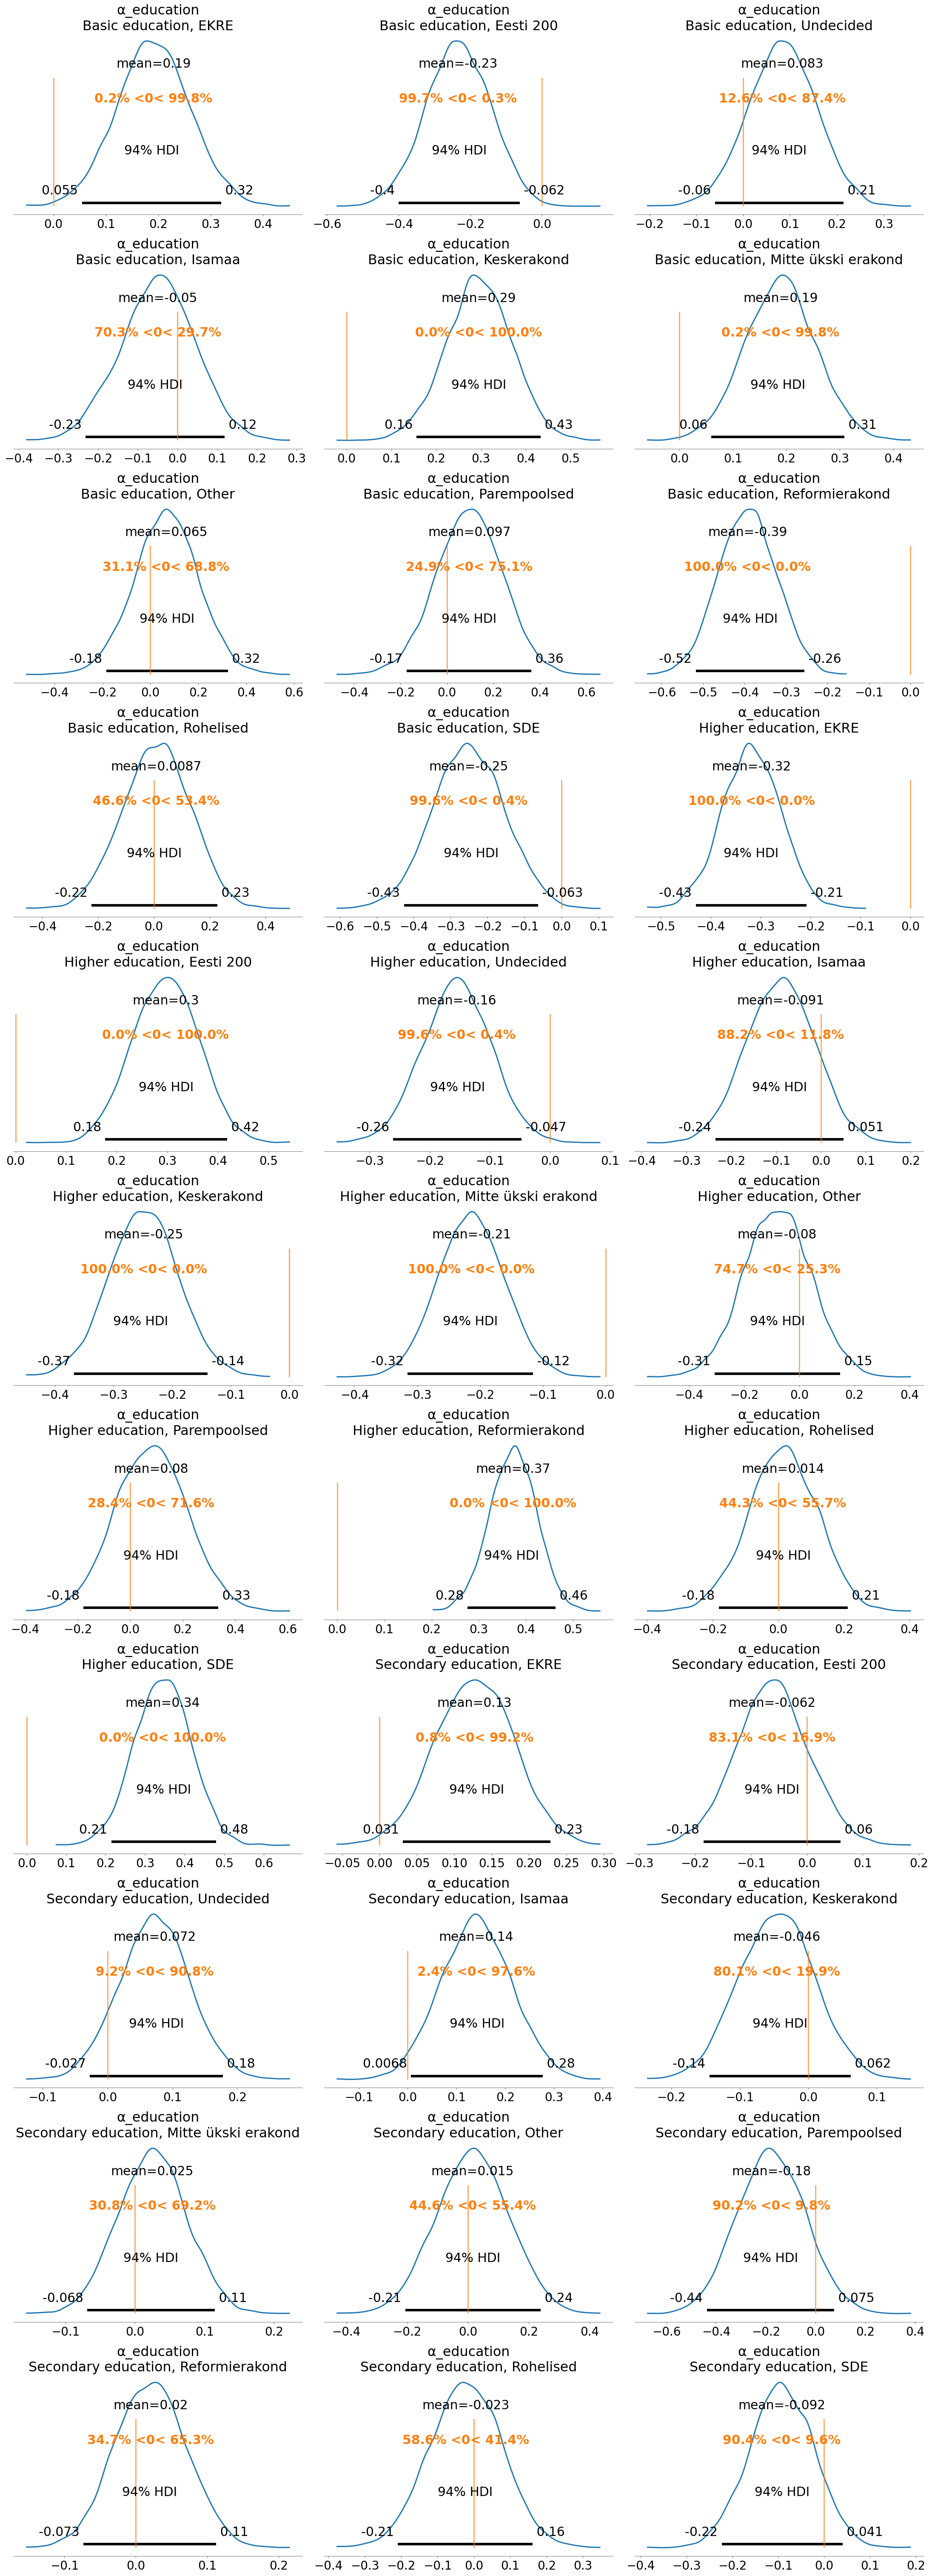

In [111]:
az.plot_posterior(idata1b, var_names='α_education', ref_val=0, backend_kwargs=dict(tight_layout=True), textsize=20);

3. Nationality
* Estonians are: 
    * predominantly favorable to EKRE, Isamaa, Reformierakond;
    * largely unfavorable to Keskerakond and Mitte, and are less likely to be Undecided.
* Ethnic Russians (Other) on the other hand:
    * favor Keskerakond, Mitte, and are more likely to be Undecided;
    * are hostile to Reformierakond and to a lesser extent EKRE.

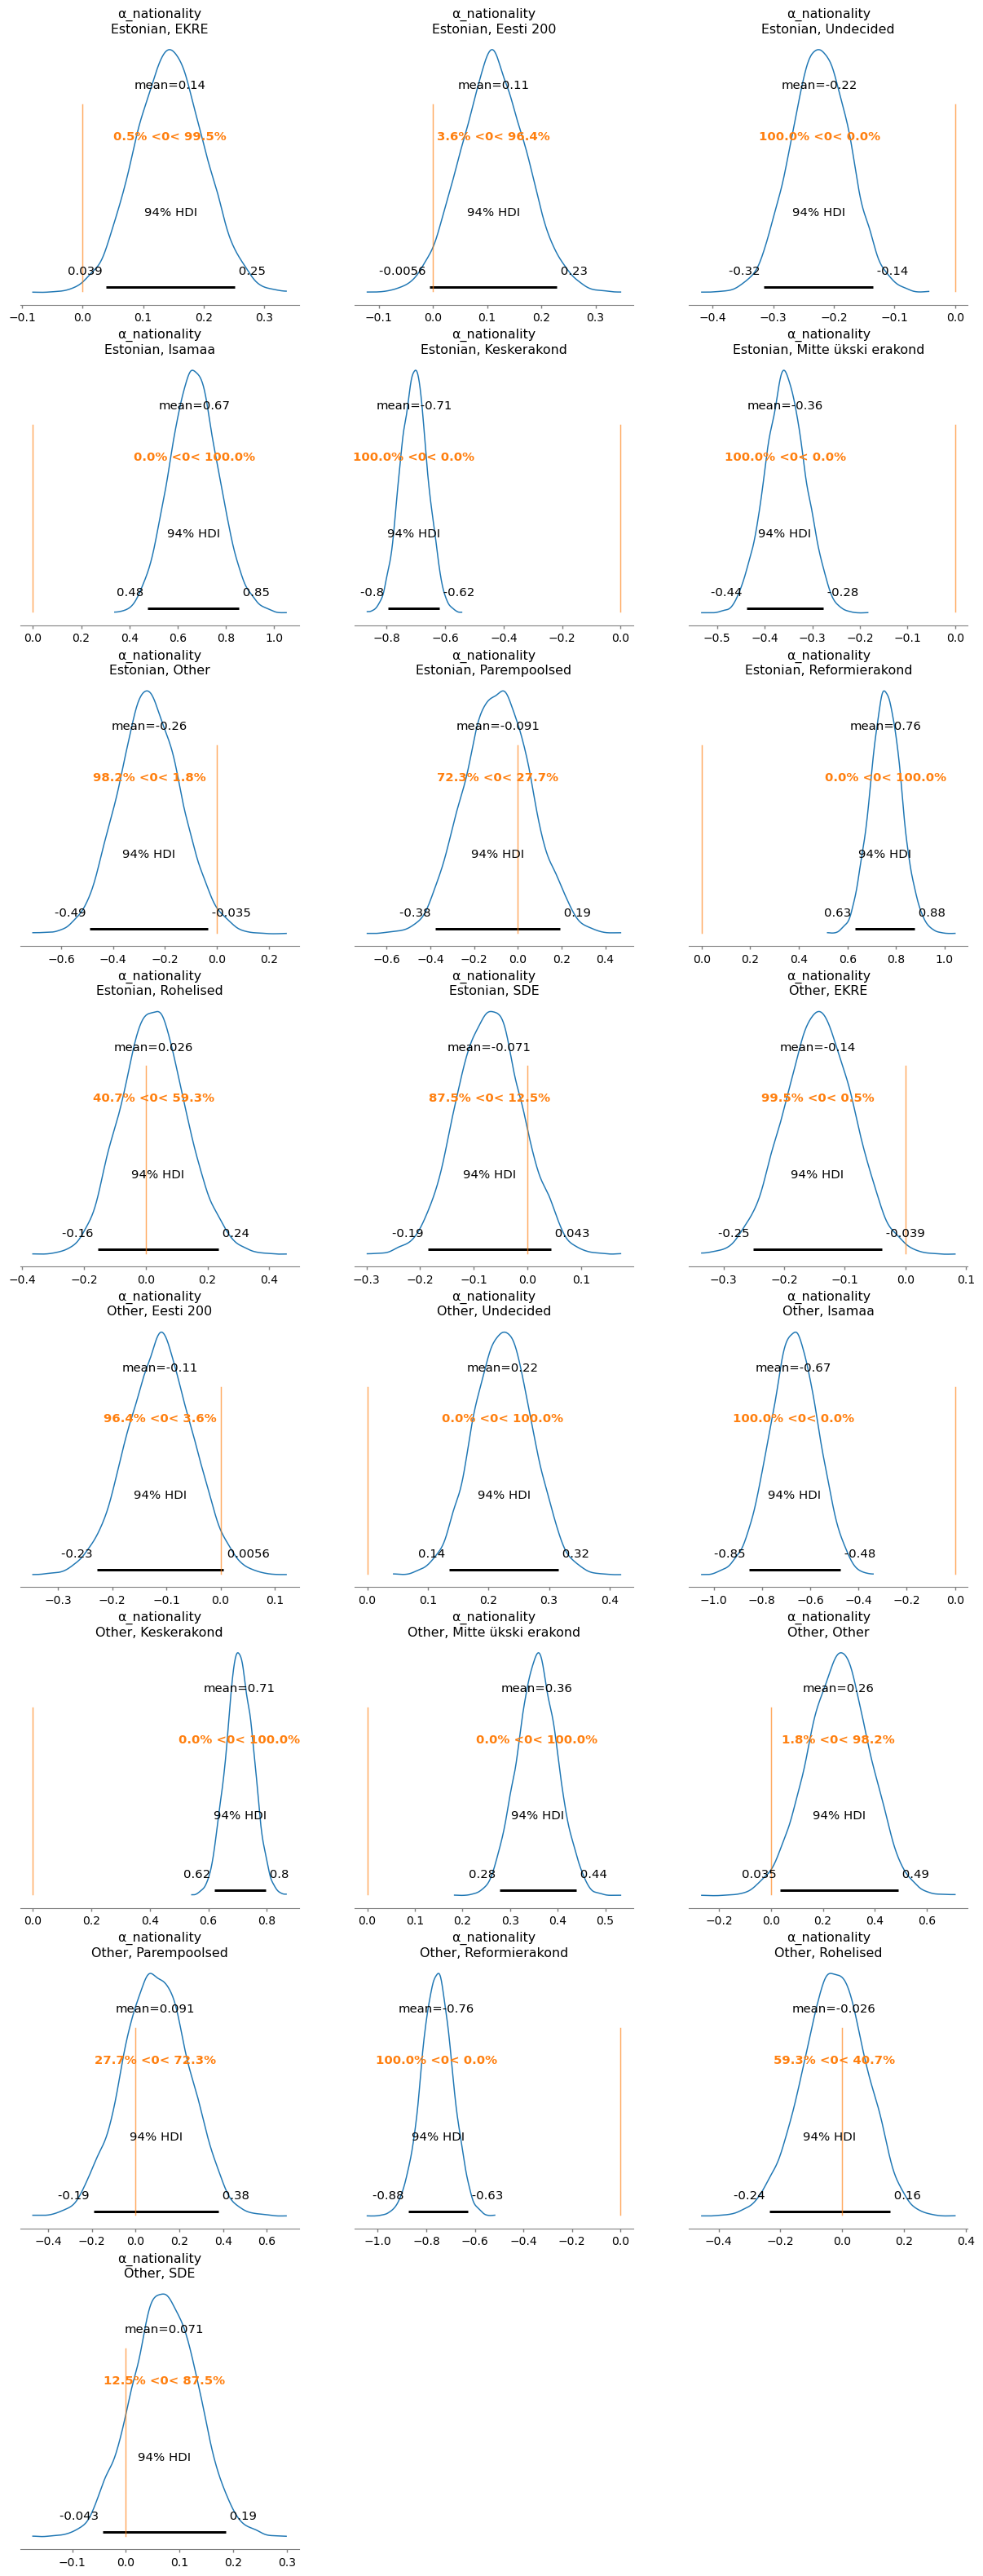

In [108]:
f, axs = pp.subplots(ncols=3, nrows=8, figsize=(15, 40))
for ax in axs.ravel()[-2:]:
    ax.set_visible(False)
az.plot_posterior(idata1b, var_names='α_nationality', backend_kwargs=dict(tight_layout=True), ref_val=0, ax=axs, textsize=10);
                

#### Adding gender and age group
In accordance with the Bayesian workflow, the next step is to build a slightly more complex model, in this case by adding gender and vote age group as predictors to nationality and education, and see if can extract further insight. The model type is the same, just with a total of 4 offsets to the baseline instead of 2. I will also use stronger informative priors as I did in the second model that I ended up using for my analysis. Finally, the prior distribution for all coefficients is again the ZeroSumNormal distribution that I use to avoid non-identifiability due to overparameterization.
But first, to encode the additional predictors...

In [118]:
gender_code, gender_label = data.gender.factorize(sort=True)
age_gp_code, age_group_label = data.age_group.factorize(sort=True)

In [124]:
coords = {
    'age group': age_group_label,
    'education': education_label,
    'gender': gender_label,
    'nationality': nationality_label,
    'party choice': party_choice_label,
    'obs_idx': data.index
}

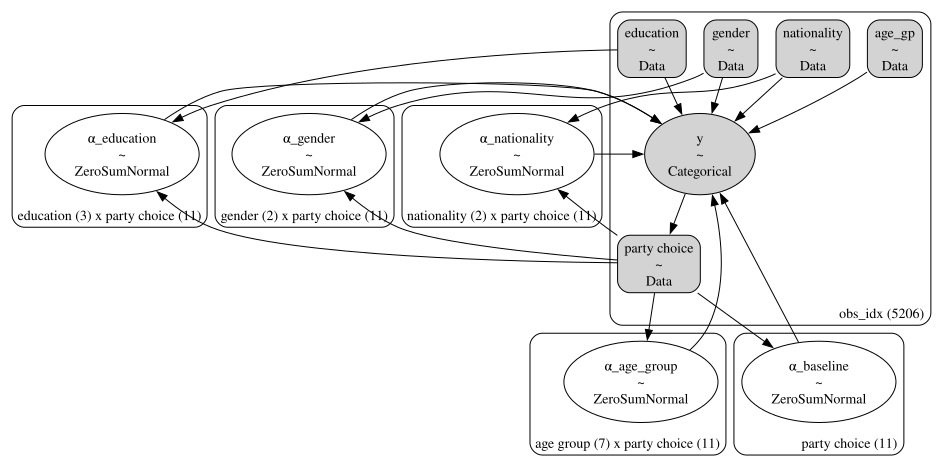

In [134]:
def build_model2(coords, σ_baseline=1, σ_age=1, σ_edu=1, σ_gen=1, σ_nat=1):
    with pm.Model(coords=coords) as model2:
        age_gp_idx = pm.Data('age_gp', age_gp_code, dims='obs_idx')
        educ_idx = pm.Data('education', education_code, dims='obs_idx')
        gender_idx = pm.Data('gender', gender_code, dims='obs_idx')
        nat_idx = pm.Data('nationality', nationality_code, dims='obs_idx')
        party_choice_idx = pm.Data('party choice', party_choice_code, dims='obs_idx') 
        
        α_baseline = pm.ZeroSumNormal('α_baseline', sigma=σ_baseline, dims='party choice')
        α_age_group = pm.ZeroSumNormal('α_age_group', sigma=σ_age, dims=('age group', 'party choice'), n_zerosum_axes=2)
        α_education = pm.ZeroSumNormal('α_education', sigma=σ_edu, dims=('education', 'party choice'), n_zerosum_axes=2)
        α_gender = pm.ZeroSumNormal('α_gender', sigma=σ_gen, dims=('gender', 'party choice'), n_zerosum_axes=2)
        α_nationality = pm.ZeroSumNormal('α_nationality', sigma=σ_nat, dims=('nationality', 'party choice'), n_zerosum_axes=2)

        μ = α_baseline + α_age_group[age_gp_idx] + α_education[educ_idx] + α_gender[gender_idx] + α_nationality[nat_idx]
        p = pm.math.softmax(μ, axis=-1)

        _ = pm.Categorical('y', p=p, observed=party_choice_idx, dims='obs_idx')
        
    return model2

model2 = build_model2(coords=coords, σ_baseline=0.3, σ_age=0.4, σ_edu=0.3, σ_gen=0.2, σ_nat=0.2)
model2.to_graphviz()